In [4]:
!pip install torchsummary

In [5]:
import os
import numpy as np
import cv2
import pickle
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# untar
!ls
!tar -xvzf dataset.tar.gz
# load train
train_images = pickle.load(open('train_images.pkl', 'rb'))
train_labels = pickle.load(open('train_labels.pkl', 'rb'))
# load val
val_images = pickle.load(open('val_images.pkl', 'rb'))
val_labels = pickle.load(open('val_labels.pkl', 'rb'))

'ls' is not recognized as an internal or external command,
operable program or batch file.


x train_images.pkl
x train_labels.pkl
x val_images.pkl
x val_labels.pkl


In [8]:
train_images = torch.tensor(train_images, dtype=torch.float32)
val_images = torch.tensor(val_images, dtype=torch.float32)

train_images = train_images.permute(0, 3, 1, 2)
val_images = val_images.permute(0, 3, 1, 2)

train_dataset = TensorDataset(train_images,
                              torch.tensor(train_labels.squeeze(), dtype=torch.long))
val_dataset = TensorDataset(val_images,
                            torch.tensor(val_labels.squeeze(), dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [9]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        self.model = nn.Sequential(
            # First block: Conv -> ReLU -> Conv -> ReLU -> MaxPool -> Dropout
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=True),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=0, bias=True),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            # Second block: Conv -> ReLU -> Conv -> ReLU -> MaxPool -> Dropout
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=True),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=0, bias=True),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            # Flatten layer
            nn.Flatten(),

            # Fully connected block: Dense -> ReLU -> Dropout -> Dense -> Softmax
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 5),
        )

    def forward(self, x):
        return self.model(x)

In [16]:
model = ConvNet()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-6)

In [10]:
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    # Progress bar for the training loop
    train_loader_tqdm = tqdm(train_loader, desc="Training", leave=False)

    for inputs, labels in train_loader_tqdm:
        optimizer.zero_grad()  # Zero the parameter gradients
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Track loss and accuracy
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        # Update tqdm description with current loss and accuracy
        train_loader_tqdm.set_postfix(loss=running_loss / total, accuracy=100 * correct / total)

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    return train_loss, train_accuracy

In [11]:
def validate(model, val_loader, criterion, device):
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    correct = 0
    total = 0

    # Progress bar for the validation loop
    val_loader_tqdm = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():  # Disable gradient calculations for validation
        for inputs, labels in val_loader_tqdm:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            # Update tqdm description with current validation loss and accuracy
            val_loader_tqdm.set_postfix(loss=val_loss / total, accuracy=100 * correct / total)

    val_accuracy = 100 * correct / total
    val_loss = val_loss / len(val_loader)
    return val_loss, val_accuracy

## **Loop**

In [12]:
def train_one_epoch_with_mask(model, train_loader, optimizer, criterion, device, weight_masks):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc="Fine-Tuning", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        with torch.no_grad():
            for name, module in model.named_modules():
                if name in weight_masks:
                    if module.weight.grad is not None:
                        module.weight.grad *= weight_masks[name]

                    if module.bias is not None and module.bias.grad is not None:
                        if isinstance(module, nn.Conv2d):
                            # Conv2d: bias mask matches output channels
                            module.bias.grad *= weight_masks[name][:, 0, 0, 0]
                        elif isinstance(module, nn.Linear):
                            # Linear: bias mask matches output neurons
                            module.bias.grad *= weight_masks[name][:, 0]

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)
    return train_loss, train_acc


In [28]:
def count_zeroed_and_total_weights(model):
    total_params = 0
    zero_params = 0

    for name, param in model.named_parameters():
        if "weight" in name:
            total_params += param.numel()
            zero_params += (param == 0).sum().item()

    print(f"Total weights     : {total_params:,}")
    print(f"Zeroed weights    : {zero_params:,}")
    print(f"Percentage pruned : {100 * zero_params / total_params:.2f}%")
    return total_params, zero_params

def pareto_frontier(k):
    # reload full model
    # model = ConvNet().to(device)
    # model.load_state_dict(torch.load('original_model.pt'))
    # print("Loaded original model weights.")

    activation_storage = {}

    def get_activation_hook(name):
        def hook(model, input, output):
            if output.dim() == 4:  # Conv2d output > [batch, channels, H, W]
                stats = output.detach().mean(dim=(2, 3))  # [batch, channels]
            elif output.dim() == 2:  # Linear output > [batch, features]
                stats = output.detach()  # [batch, features]
            else:
                raise ValueError(f"Unexpected output shape {output.shape} for layer {name}")

            if name not in activation_storage:
                activation_storage[name] = []
            activation_storage[name].append(stats.cpu())
        return hook
    
    hooks = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):  #only linear
            hooks.append(module.register_forward_hook(get_activation_hook(name)))

    model.eval()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(train_loader):
            if i >= 200:  # subset of training data
                break
            inputs = inputs.to(device)
            _ = model(inputs)

    avg_activations = {}
    for layer_name, activations in activation_storage.items():
        all_acts = torch.cat(activations, dim=0)  # [num_samples, channels]
        avg_per_filter = all_acts.mean(dim=0)     # [channels]
        avg_activations[layer_name] = avg_per_filter

    for h in hooks:
        h.remove()

    k_percent = k  # prune bottom 50%
    pruned_indices = {}

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and name in avg_activations:
            with torch.no_grad():
                weight = module.weight
                already_zeroed = (weight.abs().sum(dim=1) == 0)  # For Linear: sum across inputs
                not_zeroed_indices = (~already_zeroed).nonzero(as_tuple=True)[0]

                if not_zeroed_indices.numel() == 0:
                    continue  # All units already pruned

                avg = avg_activations[name][not_zeroed_indices.cpu()]
                num_prune = int(k_percent * len(avg))

                if num_prune == 0:
                    continue  # Nothing to prune

                # Get local indices to prune (lowest-activation units among still-alive ones)
                prune_local_idx = torch.argsort(avg)[:num_prune]
                prune_idx = not_zeroed_indices[prune_local_idx]

                pruned_indices[name] = prune_idx

                module.weight[prune_idx, :] = 0
                if module.bias is not None:
                    module.bias[prune_idx] = 0


    print("Pruning complete")

    weight_masks = {}

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            mask = torch.ones_like(module.weight)

            if name in pruned_indices:
                idx = pruned_indices[name]
                
                # Conv2d > zero out filters (along output channels)
                if isinstance(module, nn.Conv2d):
                    mask[idx] = 0
                
                # Linear > zero out neurons (rows of the weight matrix)
                elif isinstance(module, nn.Linear):
                    mask[idx, :] = 0

            weight_masks[name] = mask

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-6)

    # fine-tuning epochs
    for epoch in range(7):
        train_loss, train_accuracy = train_one_epoch_with_mask(model, train_loader, optimizer, criterion, device, weight_masks)
        val_loss, val_accuracy = validate(model, val_loader, criterion, device)
        print(f'[Fine-Tuning Epoch {epoch+1}] Val Accuracy: {val_accuracy:.2f}%')

    val_loss, val_accuracy = validate(model, val_loader, criterion, device)

    total_params, zero_params = count_zeroed_and_total_weights(model)

    sparsity = (zero_params / total_params) * 100

    return val_accuracy, sparsity

    

In [20]:
model = ConvNet().to(device)
model.load_state_dict(torch.load('original_model.pt'))
print("Loaded original model weights.")

Loaded original model weights.


C:\Users\nickc\AppData\Local\Temp\ipykernel_2168\435407500.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('original_model.pt'))



=== Running pruning with k = 0.15 ===
Pruning complete


[Fine-Tuning Epoch 1] Val Accuracy: 68.95%


[Fine-Tuning Epoch 2] Val Accuracy: 69.43%


[Fine-Tuning Epoch 3] Val Accuracy: 69.03%


[Fine-Tuning Epoch 4] Val Accuracy: 69.23%


...

[Fine-Tuning Epoch 4] Val Accuracy: 68.04%


[Fine-Tuning Epoch 5] Val Accuracy: 68.59%


[Fine-Tuning Epoch 6] Val Accuracy: 68.04%


[Fine-Tuning Epoch 7] Val Accuracy: 68.08%


Total weights     : 592,224
Zeroed weights    : 457,728
Percentage pruned : 77.29%


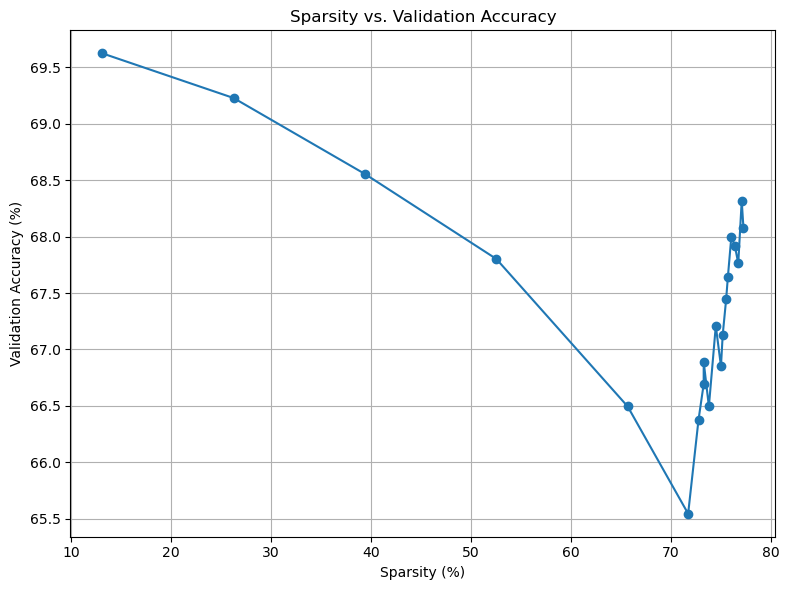

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Generate 20 values of k evenly spaced from 0 to 0.9
k_values = np.linspace(0, 0.9, 30)
k_values = [0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15]

accuracies = []
sparsities = []

for k in k_values:
    print(f"\n=== Running pruning with k = {k:.2f} ===")
    val_acc, sparsity = pareto_frontier(k)
    accuracies.append(val_acc)
    sparsities.append(sparsity)

# Plotting sparsity vs. validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(sparsities, accuracies, marker='o')
plt.xlabel('Sparsity (%)')
plt.ylabel('Validation Accuracy (%)')
plt.title('Sparsity vs. Validation Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()


=== Running pruning with k = 0.15 ===
Pruning complete


[Fine-Tuning Epoch 1] Val Accuracy: 71.37%


[Fine-Tuning Epoch 2] Val Accuracy: 71.41%


[Fine-Tuning Epoch 3] Val Accuracy: 71.52%


[Fine-Tuning Epoch 4] Val Accuracy: 71.05%


...

[Fine-Tuning Epoch 4] Val Accuracy: 63.01%


[Fine-Tuning Epoch 5] Val Accuracy: 62.42%


[Fine-Tuning Epoch 6] Val Accuracy: 62.97%


[Fine-Tuning Epoch 7] Val Accuracy: 63.56%


Total weights     : 592,224
Zeroed weights    : 518,144
Percentage pruned : 87.49%
Saved trained model for future pruning.


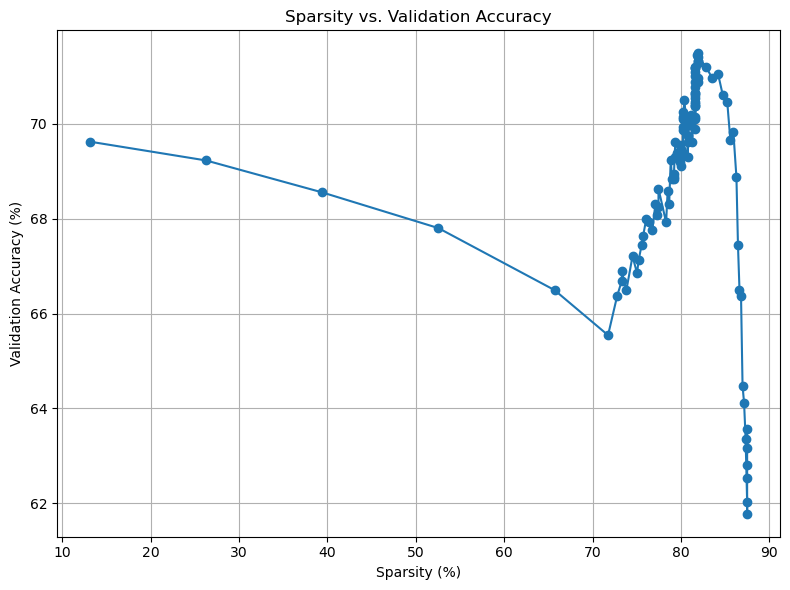

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate 20 values of k evenly spaced from 0 to 0.9
k_values = np.linspace(0, 0.9, 30)
#k_values = [0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15]

# accuracies = []
# sparsities = []

for k in k_values:
    print(f"\n=== Running pruning with k = {k:.2f} ===")
    val_acc, sparsity = pareto_frontier(k)
    accuracies.append(val_acc)
    sparsities.append(sparsity)
    score = (val_acc/100 + sparsity/100 ) / 2
    filename = f"score_{score:.5f}.pt"
    torch.save(model.state_dict(), filename)
    print("Saved trained model for future pruning.")

import csv

# Save results to a CSV
with open('k=0.15_iterative_sparsity_vs_accuracy.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Sparsity (%)', 'Validation Accuracy (%)'])  # header
    for s, a in zip(sparsities, accuracies):
        writer.writerow([f"{s:.2f}", f"{a:.2f}"])

# Plotting sparsity vs. validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(sparsities, accuracies, marker='o')
plt.xlabel('Sparsity (%)')
plt.ylabel('Validation Accuracy (%)')
plt.title('Sparsity vs. Validation Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
finetuned_sparsities = sparsities
finetuned_accuracies = accuracies

In [31]:
def is_dominated(s1, a1, s2, a2):
    return (s2 >= s1 and a2 >= a1) and (s2 > s1 or a2 > a1)

def get_pareto_frontier(sparsities, accuracies):
    points = sorted(zip(sparsities, accuracies), key=lambda x: x[0])  # sort by sparsity
    pareto = []

    for s, a in points:
        if not any(is_dominated(s, a, ps, pa) for ps, pa in pareto):
            pareto.append((s, a))
    
    pareto_s, pareto_a = zip(*pareto)
    return pareto_s, pareto_a


In [19]:
import csv

# Save results to a CSV
with open('fine_tuned_sparsity_vs_accuracy.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Sparsity (%)', 'Validation Accuracy (%)'])  # header
    for s, a in zip(finetuned_sparsities, finetuned_accuracies):
        writer.writerow([f"{s:.2f}", f"{a:.2f}"])

In [23]:
import csv

# Save results to a CSV
with open('sparsity_vs_accuracy.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Sparsity (%)', 'Validation Accuracy (%)'])  # header
    for s, a in zip(sparsities, accuracies):
        writer.writerow([f"{s:.2f}", f"{a:.2f}"])

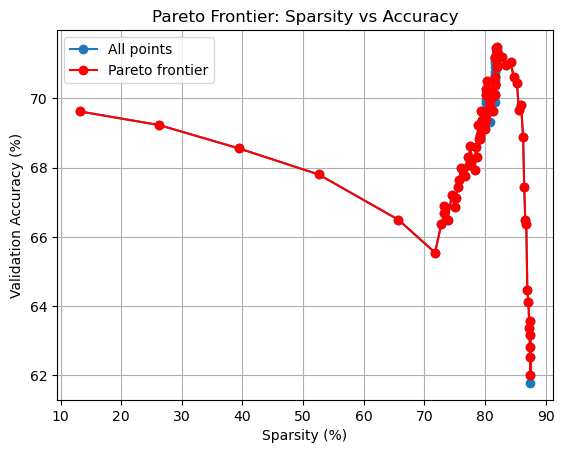

In [32]:
# Get Pareto frontier
pareto_sparsities, pareto_accuracies = get_pareto_frontier(sparsities, accuracies)

# Plot full sweep
plt.plot(sparsities, accuracies, 'o-', label="All points")
# Plot Pareto-optimal points
plt.plot(pareto_sparsities, pareto_accuracies, 'ro-', label="Pareto frontier")

plt.xlabel('Sparsity (%)')
plt.ylabel('Validation Accuracy (%)')
plt.title('Pareto Frontier: Sparsity vs Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [34]:
model = ConvNet().to(device)
model.load_state_dict(torch.load('score_0.77878.pt'))
val_loss, val_accuracy = validate(model, val_loader, criterion, device)
print(f"Post-Pruning Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

def count_zeroed_and_total_weights(model):
    total_params = 0
    zero_params = 0

    for name, param in model.named_parameters():
        if "weight" in name:
            total_params += param.numel()
            zero_params += (param == 0).sum().item()

    print(f"Total weights     : {total_params:,}")
    print(f"Zeroed weights    : {zero_params:,}")
    print(f"Percentage pruned : {100 * zero_params / total_params:.2f}%")
    return total_params, zero_params

total_params, zero_params = count_zeroed_and_total_weights(model)


#print(f"k percent: {k_percent}")
print(f"Final Validation Accuracy: {val_accuracy}")
#score = (accuracy + num zero weights / total parameters) / 2

score = (val_accuracy/100 + zero_params / total_params ) / 2
print("Score must be .36 or higher")
print(f"Final score for assignment: {score}")

C:\Users\nickc\AppData\Local\Temp\ipykernel_2168\3356244358.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('score_0.77878.pt'))
Validat

Post-Pruning Val Loss: 0.8119, Val Accuracy: 69.82%
Total weights     : 592,224
Zeroed weights    : 508,928
Percentage pruned : 85.94%
Final Validation Accuracy: 69.82178217821782
Score must be .36 or higher
Final score for assignment: 0.7787841689015715
